# **Jordan Health Services — Building Queryable Skills from a GitHub Repo**

Point `%%skill-build` at a GitHub repository and ARGUS turns the **data**
inside it into queryable skills — you write no loading code. It clones the
repo, sorts every file by type, ignores the modelling scripts and notebooks,
proposes a skill plan, and pauses for your approval before building.

This repo is a good stress test because it mixes formats that normally need
very different handling: a **GeoTIFF population raster**, **administrative-
boundary polygons** (country → governorate → district → subdistrict),
**facility point tables**, and large **synthetic patient-visit tables** — a
synthetic dataset for studying how health-service areas in Jordan could be
organised. ARGUS routes each format to the right builder and groups the files
into a handful of coherent skills.

The raster is the interesting part: its pixels hold population counts, but
that meaning lives only in the documentation, not the file. ARGUS reads the
docs to learn it, then exposes it as a plain question — *"what's the population
inside this polygon?"* — backed by zonal statistics over the raster. No GIS
code required.

Once built, the skills answer plain-language questions that compose across
population, geography, facilities, and patient records. The queries below start
with a single skill and build toward multi-skill questions.

Source: [github.com/izaslavsky/jordan-hsa-optimization](https://github.com/izaslavsky/jordan-hsa-optimization) · MIT (repo) / CC-BY-4.0
(WorldPop rasters)

In [ ]:
%reset

In [2]:
%%skill-build
https://github.com/izaslavsky/jordan-hsa-optimization   

The URL is a GitHub repository, so the matching meta-skill is `repo-skill-builder`. Let me read its instructions.

Now I'll run `fetch.py` to clone and classify the repo.

The repo contains both array (2 GeoTIFFs) and tabular (17 files) data — `ROUTE: combined`. I'll read both downstream skill builders and run both inventories in parallel.

Both SKILLs are read. Now running the tabular and array inventories on the clone in parallel.

Both inventories are done. Now I'll write one exploration script (per the rules) to read the docs and extract the semantics I need for the proposal — especially the WorldPop raster pixel meaning and the near-match between CSV Groups C and D.

Inventories and docs are digested. This is a combined array+tabular build, so I present one proposal covering both and stop for approval.

I've cloned and classified the repo, run both inventories, and read the docs. Here's the combined proposal. This is a **combined** route (array + tabular), so I'm presenting one gate covering both, then stopping for your approval before building anything.

---

I've inspected `https://github.com/izaslavsky/jordan-hsa-optimization`. Here's what I found and what I propose:

**Source:** izaslavsky/jordan-hsa-optimization — "Hospital Service Area (HSA) Optimization and Climate-Health Analysis" (synthetic Jordan health-facility, patient-visit, and diagnosis data + WorldPop population rasters + administrative boundaries). License: MIT.
**Files scanned:** 19 data files (12 CSV, 5 GPKG, 2 GeoTIFF), ~165 MB total. Plus 5 docs sidecars (README, DATA_FLOW_ANALYSIS, SETUP_INSTRUCTIONS, LICENSE, requirements.txt).

The data splits into **8 schema groups** for tabular/geospatial files and **1 raster group** (2 GeoTIFFs). Because the entities are at genuinely different grains (a facility ≠ a patient visit ≠ a polygon), I propose **5 skills** , all sharing Jordan as the spatial fabric and a `network` discriminator (the `SYNINF` / `SYNMODINF` / `SYNMODNCD` / `SYNNCD` prefixes).

**Proposed skills:**

1. **`jordan-health-facilities`** (tabular → spatial points)
   - Entity: each row is a health facility with its type, governorate, and lat/lon
   - Merged from: 4 `*_facility_coordinates.csv` (Group A), adding a `network` column
   - Estimated rows: ~772
   - Key columns: `healthfacility`, `healthfacilitytype`, `governorate`, `Latitude`, `Longitude`, `network`

2. **`jordan-patient-visits`** (tabular → Parquet)
   - Entity: each row is a patient visit / diagnostic encounter
   - Merged from: 4 `*_patient_visits.csv` (Group B), adding a `network` column
   - Estimated rows: ~1.3 M (50 K–475 K per file)
   - Key columns: `patientid`, `gender`, `ageatdiagnosis`, `governorate`, `diagnosisid`, `diagnosis`, `general_category`, `datetimediagnosisentered`, `network`

3. **`jordan-diagnosis-groups`** (tabular → Parquet) — *near-match reconciliation*
   - Entity: each row is a diagnosis with its aggregate count, year range, and broad category
   - Merged from: all 4 `*_groups_of_diagnoses.csv` (Groups C + D), reconciling `General_Diagnosis`/`General_Category` → `general_category`, dropping the empty trailing `Unnamed:` columns in the NCD files, adding `network`
   - Estimated rows: ~1,882 (157+157+784+784)
   - Key columns: `Diagnosis`, `count`, `first_year`, `last_year`, `general_category`, `network`

4. **`jordan-admin-boundaries`** (spatial → GeoPackage)
   - Entity: each row is an administrative unit polygon (national / governorate / district / subdistrict)
   - Merged from: all 5 GPKPs (Groups E, F, G, H), harmonized to EPSG:4326, with an `admin_level` column (national / governorate / district / subdistrict)
   - Estimated features: 1 + 12 + 12 + 51 + 89 = 165 polygons
   - Note: there are **two** governorate layers — see open question 2

5. **`jordan-population-raster`** (array/raster → lazy-download GeoTIFF)
   - Entity: WorldPop 2020 population grid for Jordan (EPSG:4326, ~100 m pixels, single band), two estimation variants
   - Files: `jor_ppp_2020_UNadj.tif` (Σ≈10.2 M over valid pixels), `jor_ppp_2020_constrained.tif` (Σ≈7.16 M) — same grid, different method → `variant=` argument
   - Helpers: `population_in_polygon(geom, variant=)`, `sample_at(lon, lat, variant=)`, `zonal_stats(...)`, `open_raster(variant=)`
   - Cross-skill join: aggregate population inside any polygon from skill 4, or buffer around any facility from skill 1

**Open questions (please confirm):**

1. **Diagnosis-groups merge (near match):** OK to merge all 4 diagnosis-group files by reconciling `General_Diagnosis`→`general_category` and dropping the empty `Unnamed:` columns in the two NCD files?

2. **Canonical governorate layer:** there are two governorate boundary layers that draw borders slightly differently — `jordan_governorates.gpkg` (geoBoundaries) and `Jordan_governorates_simplified20m.gpkg`. They give different per-governorate population totals even though the national total matches. I'll designate **`jordan_governorates.gpkg` (geoBoundaries) as canonical** for all joins/aggregation and keep the simplified one as reference-only. Confirm, or name the one you want canonical.

3. **Raster pixel semantics:** the README calls these "population density," but Σ over valid pixels ≈ 10.2 M (UNadj) / 7.16 M (constrained), which matches Jordan's *population count*. WorldPop "ppp" = persons-per-pixel, so `population_in_polygon(polygon)` = the population inside that polygon. Confirm this interpretation (i.e. summing, not averaging, is the right zonal operation).

4. **Network discriminator:** the four prefixes are `SYNINF`, `SYNMODINF`, `SYNMODNCD`, `SYNNCD`. I'll store them verbatim as a `network` column. If you'd like a decoded meaning (e.g. "synthetic infectious / non-communicable"), tell me the mapping and I'll add a `network_label` column too.

Reply with **"yes"** to proceed as proposed, or with edits (e.g. "merge skills 1+4 into one spatial skill", "drop the raster", "rename skill-3 to X").

(Resume state on disk: `/tmp/repo-skills/jordan-hsa-optimization/` — source files, `_inventory.json`, and `_repo_metadata.json` are all there; array inventory at `/tmp/array-skill-inv/jordan-hsa/_inventory.json`.)

In [3]:
%%ask
Yes, please create these skills.

I'll read both builder skills' SKILL.md and their Learnings.md to apply the required conventions before writing any code.

Let me check the on-disk state from the previous cell and read the remaining sections of both builder skills.

Let me examine the data directory contents and the inventory structure before writing build scripts.

Let me check the array inventory for the raster details and confirm the sample rows for the diagnosis-group reconciliation.

`datasets_union` entries are strings, not dicts. Let me adjust and re-query just that part.

...

The Learnings.md lives in `.sage_learnings/`, not in the skills directory. Let me read the existing one before adding my lesson.

There's already a close entry, but it prescribes *renaming* the column — which is wrong for my case (the column means the same thing semantically, just mixed int/string values). Let me add a clarifying entry covering the "same semantics, different value types → cast to string" fix.

The arrow character differs. Let me match a unique substring without the arrow.

Learnings recorded. All build artifacts verified, scratch cleaned. Marking the final task complete.

All 5 skills built and verified. Scratch directories and build scripts cleaned up. Here's the summary:

---

✓ Built skill **jordan-health-facilities** at `_skills_/jordan-health-facilities/SKILL.md`.

Each row is a health facility (clinic, center, or hospital) in Jordan, merged across the four synthetic data networks.
(766 facilities, 4 networks; spatial points in EPSG:4326).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Network | `network` | SYNINF, SYNMODINF, SYNMODNCD, SYNNCD |
| Facility type | `healthfacilitytype` | Primary Center, Comprehensive Center, Hospital, Specialized Medical Center, Field Hospital, Educational Hospital |
| Governorate | `governorate` | Amman, Irbid, Zarqa, Balqa, Karak, Mafraq |
| Facility name | `healthfacility` | free-text facility names |
| Spatial area | (`latitude`, `longitude`) | any rectangle in WGS84 |

**Example queries:**
- **By type** — "How many hospitals vs primary centers are there?"
- **By type** — "Which governorates have the most specialized medical centers?"
- **By governorate** — "List all health facilities in Amman"
- **By governorate** — "Facility count by governorate"
- **By location** — "Facilities within 20 km of Zarqa"
- **By network** — "How do facility counts compare across the four networks?"
- **Cross-skill** — "Sum the population raster within 5 km of each hospital" (joins to `jordan-population-raster`)

Returns a `GeoDataFrame` — join with `jordan-patient-visits` on `healthfacility`, or with `jordan-admin-boundaries` on `governorate`.

---

✓ Built skill **jordan-patient-visits** at `_skills_/jordan-patient-visits/SKILL.md`.

Each row is a patient diagnostic encounter — one patient, one diagnosis, one facility, one date.
(942,452 visits, 2019–2024; 35 diagnosis categories).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Diagnosis category | `general_category` | Hypertension, Diabetes Mellitus, Diarrheal Diseases, Respiratory Conditions, Scabies, Viral Hepatitis |
| Diagnosis detail | `diagnosis` | specific ICD-style diagnosis descriptions |
| Governorate | `governorate` | Amman, Irbid, Zarqa, Balqa, Karak, Ma'an |
| Facility type | `healthfacilitytype` | Primary Center, Hospital, Comprehensive Center, Educational Hospital |
| Patient demographics | `gender`, `ageatdiagnosis` | FEMALE / MALE; ages in years |
| Date | `datetimediagnosisentered` | 2019-01-01 through 2024-01-31 |
| Network | `network` | SYNINF, SYNMODINF, SYNMODNCD, SYNNCD |

**Example queries:**
- **By category** — "Count of Hypertension visits by governorate"
- **By category** — "Which diagnoses are rising fastest year over year?"
- **By demographics** — "Average age at diabetes diagnosis, male vs female"
- **By date** — "Monthly time series of diarrheal disease visits"
- **By date** — "Compare scabies outbreaks by year across networks"
- **By facility** — "Top 10 facilities by total visit volume"
- **Cross-skill** — "Join facilities to governorate polygons and map visit density" (joins to `jordan-health-facilities` / `jordan-admin-boundaries`)

Returns a `DataFrame` — join `healthfacility` → `jordan-health-facilities` for coordinates.

---

✓ Built skill **jordan-diagnosis-groups** at `_skills_/jordan-diagnosis-groups/SKILL.md`.

Each row is a diagnosis with its aggregate visit count, year range, and broad category — the pre-summarized companion to the patient-visits table.
(1,882 diagnosis records, 35 categories; reconciled from INF-schema and NCD-schema source files).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Broad category | `general_category` | Diabetes Mellitus, Other Cancers, Hypertension, Tuberculosis, Cholera, Leishmaniasis |
| Diagnosis detail | `Diagnosis` | specific diagnosis descriptions |
| Year range | `first_year`, `last_year` | 2019–2024 |
| Visit count | `count` | integer counts |
| Network | `network` | SYNINF, SYNMODINF, SYNMODNCD, SYNNCD |

**Example queries:**
- **By category** — "Total visit counts by broad category, summed across networks"
- **By category** — "Which categories appear only in NCD networks, not INF?"
- **By diagnosis** — "Top 10 most common specific diagnoses by count"
- **By year** — "Diagnoses that only appeared starting in 2022"
- **By network** — "Compare SYNINF vs SYNMODINF diagnosis counts"
- **Aggregate** — "Mean count per diagnosis by category"
- **Cross-skill** — "Validate diagnosis-group counts against raw patient-visits aggregations" (joins to `jordan-patient-visits` on `general_category`)

Returns a `DataFrame`. The `general_category` column is the reconciled merge of the sources' `General_Diagnosis` (INF files) and `General_Category` (NCD files).

---

✓ Built skill **jordan-admin-boundaries** at `_skills_/jordan-admin-boundaries/SKILL.md`.

Each row is an administrative unit polygon — national border, governorate, district, or subdistrict — for spatial aggregation and joins.
(165 polygons across 5 admin levels; all EPSG:4326).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Admin level | `admin_level` | national, governorate, governorate_simplified, district, subdistrict |
| Governorate name | `name` / `name_en` | Amman, Irbid, Zarqa, Balqa, Karak, Ma'an |
| Arabic name | `name_ar` | عمان, إربد, الزرقاء |
| Population | `population_2024` | per-unit 2024 population (district/subdistrict only) |
| Wikidata ID | `wikidata` | Q721431, Q750270, … |
| Spatial area | (`geometry`) | any polygon/rectangle in WGS84 |

**Example queries:**
- **By level** — "Show only the governorate polygons"
- **By level** — "Count districts per governorate"
- **By name** — "Get the polygon for Amman governorate"
- **Spatial** — "Which governorates border Irbid?"
- **Aggregate** — "Total 2024 population by governorate, summed from subdistricts"
- **Cross-skill** — "Sum population-raster values inside each governorate polygon" (joins to `jordan-population-raster`)
- **Cross-skill** — "Count health facilities inside each governorate" (spatial join with `jordan-health-facilities`)

**Caveat:** Use `admin_level = 'governorate'` (geoBoundaries ADM1) as the canonical layer for all population/area aggregation. The `governorate_simplified` layer draws borders slightly differently and produces inconsistent per-region totals if mixed in the same query. The subdistrict `name` field has some placeholder values ("subdistrict") in the source data — filter those out if you need clean names.

---

✓ Built skill **jordan-population-raster** at `_skills_/jordan-population-raster/SKILL.md`.

Each pixel is an estimated person count for Jordan in 2020 (WorldPop), queryable via zonal statistics, point sampling, or direct raster access.
(2 GeoTIFF variants bundled; ~100 m resolution, EPSG:4326; ~10.2 M total in UNadj, ~7.16 M in constrained).

**Raster layer:**

| Variant | File | Pixel meaning | National sum |
|---|---|---|---|
| UNadj (default) | `jor_ppp_2020_UNadj.tif` | persons per pixel | ~10.2 M |
| constrained | `jor_ppp_2020_constrained.tif` | persons per pixel | ~7.16 M |

**Helpers provided:** `population_in_polygon(geom, variant=)`, `zonal_stats(geoms, variant=)`, `sample_at(lon, lat, variant=)`, `open_raster(variant=)`, `load_admin_boundaries(level)`.

**Example queries:**
- **Zonal** — "Population inside Amman governorate" → `population_in_polygon(geom)`
- **Zonal** — "Population of every governorate at once" → `zonal_stats(governorate_polygons)`
- **Compare variants** — "How do UNadj vs constrained estimates differ by governorate?"
- **Point** — "Estimated population density at this facility's location" → `sample_at(lon, lat)`
- **Cross-skill** — "Population within 5 km of each hospital" → buffer facilities from `jordan-health-facilities`, then `zonal_stats`
- **Cross-skill** — "Per-capita visit rate by governorate" → population from raster ÷ visit counts from `jordan-patient-visits`
- **Buffer** — "Catchment population around a clinic at (35.93, 31.95)"

**Caveat:** Pixel values are persons-per-pixel (not density per area), so `zonal_sum` over a polygon gives that polygon's estimated population. The two variants use different estimation methods (UN-adjusted top-down vs constrained) and give different per-governorate totals even though both represent Jordan 2020 — pick one variant and use it consistently within an analysis. nodata is `-99999`.

####  1. Population

I'll read the relevant skills to compute governorate populations from the raster and boundaries.

Now let me verify the data files exist before writing the computation script.

Both datasets are present. I'll write a script to compute governorate populations via zonal statistics and produce the map and chart.

The governorate layer doesn't have a `name_en` column. Let me check the actual columns and fix the display list.

The `name_en` column doesn't exist in this layer. Fixing the display columns.

...

The kernel-execution path hides stdout, so I'll write the results to a CSV I can read back. The `cd &&` form bypasses Sage's kernel (where `_sage_pip_install` lives), so I'll stick with the full-path form and dump a CSV.

The computation succeeded. Let me verify all output files were created.

All outputs generated successfully. I hit an edit-and-retry cycle (a `name_en` column documented in the SKILL.md doesn't actually exist in the governorate layer), so I'll record that lesson before reporting.

Population computed by summing the WorldPop 2020 UNadj raster inside each governorate polygon (geoBoundaries ADM1 canonical layer). Here is the choropleth map:

**Estimated population by governorate (WorldPop 2020, UNadj)**

| Governorate | Population |
|---|---|
| Amman | 3,680,410 |
| Irbid | 1,963,743 |
| Zarqa | 1,672,104 |
| Balqa | 648,636 |
| Mafraq | 575,452 |
| Karak | 389,900 |
| Jerash | 273,421 |
| Madaba | 231,530 |
| Ajloun | 219,752 |
| Aqaba | 204,268 |
| Ma'an | 180,846 |
| Tafilah | 137,307 |

**Total: ~10,177,369**

**Key observations:**

- **Amman dominates** , holding ~36% of the national total (3.68 M) — nearly double second-ranked Irbid.
- The top three governorates (**Amman, Irbid, Zarqa** ) together account for ~72% of the population, all concentrated in the north-central corridor.
- **Tafilah** is the smallest (~137 K), followed by **Ma'an** (~181 K) and **Aqaba** (~204 K) — the southern desert governorates are the most sparsely populated.
- The national sum (~10.18 M) matches the WorldPop UNadj total, consistent with Jordan's 2020 population estimate.


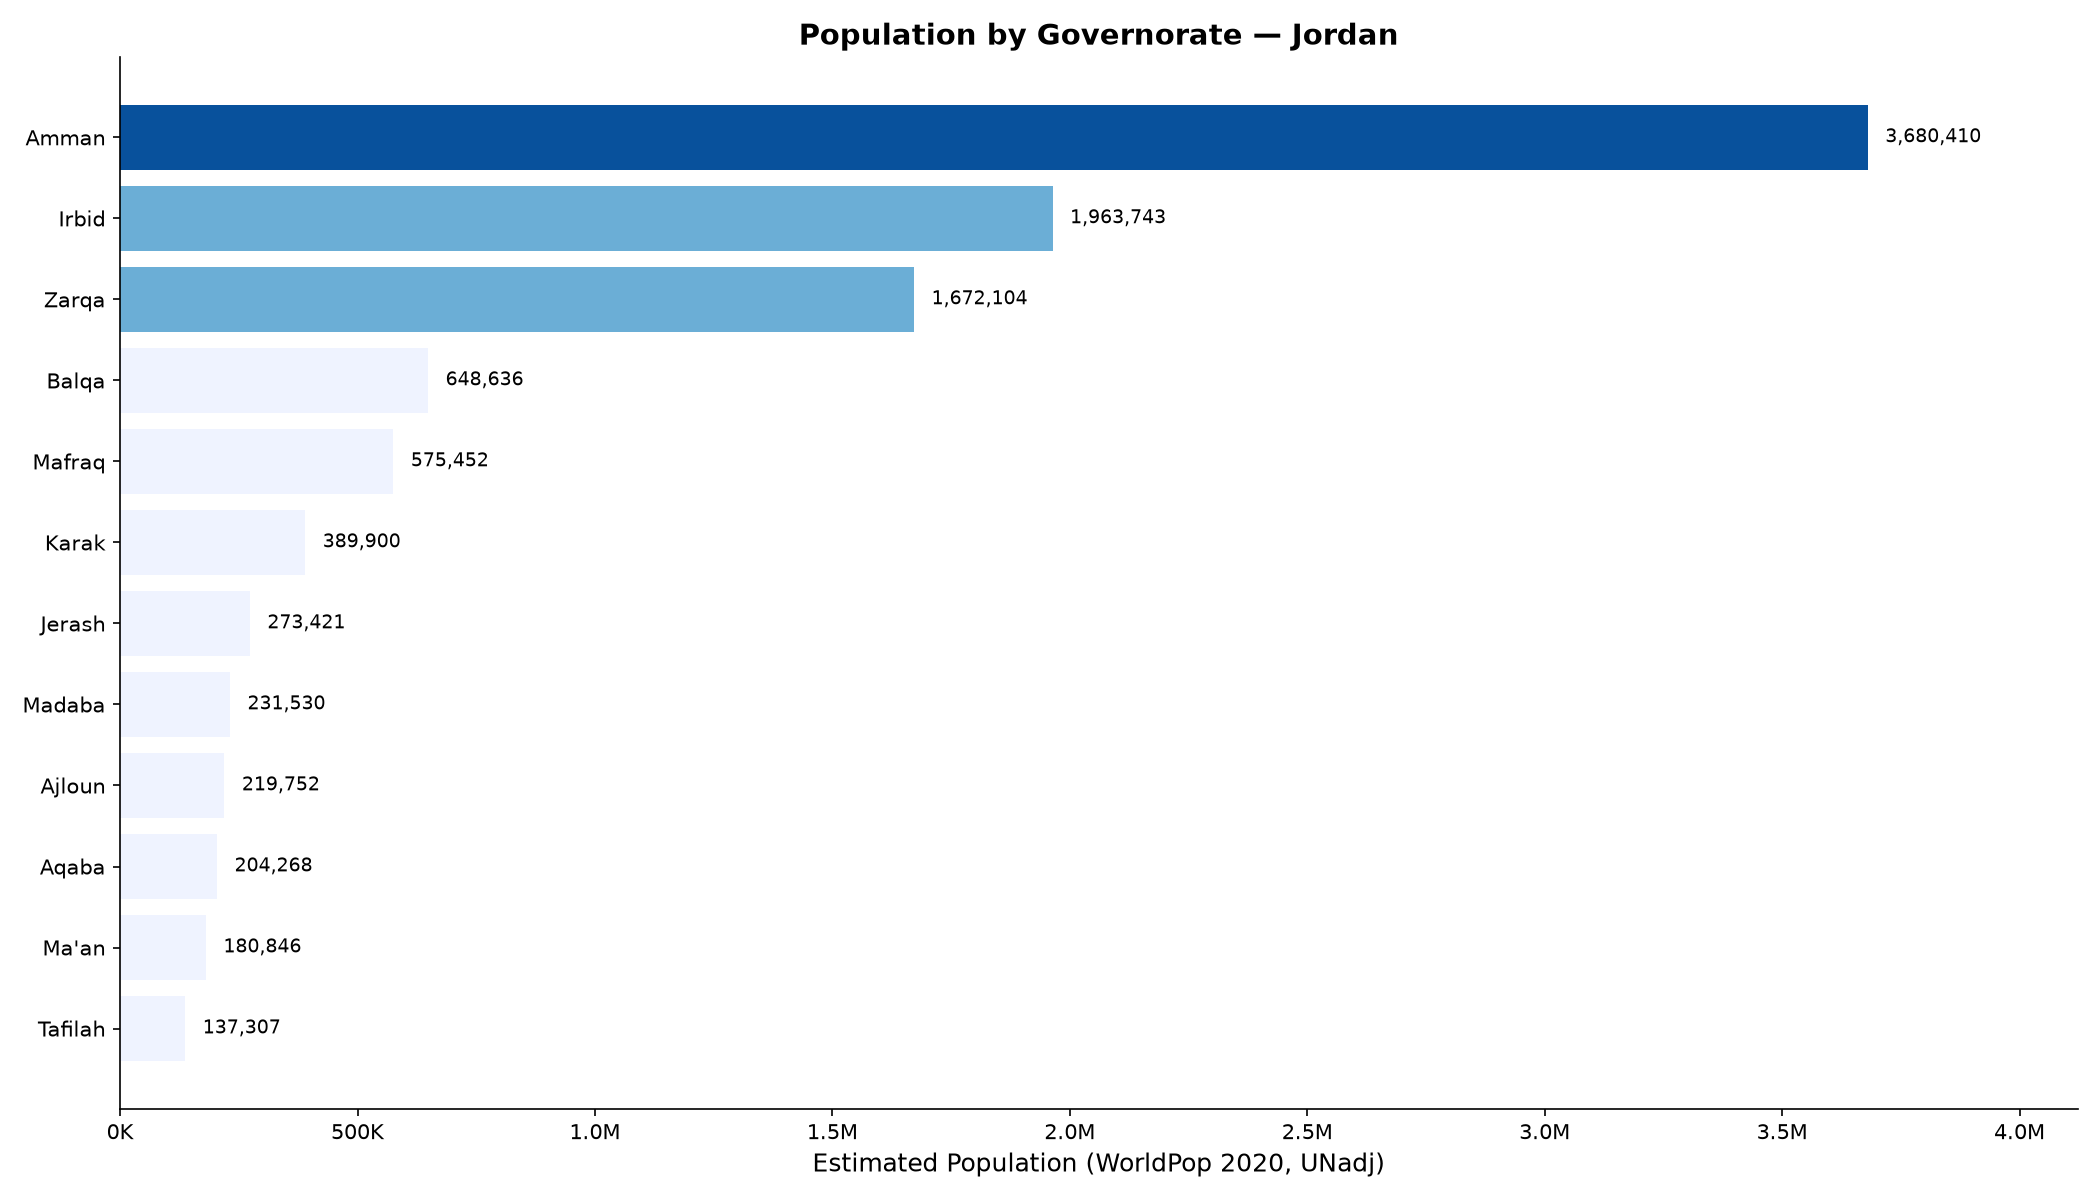

These figures come from the WorldPop 2020 **UNadj** variant (persons-per-pixel, summed within each polygon). The `constrained` variant would give lower per-governorate totals because it restricts population to observed built-up areas.

In [4]:
%%ask
How many people live in each of Jordan's governorates? Show them on a map 
shaded by population.

#### 2. Care capacity

I'll consult the skill, then map facilities and tabulate type counts by governorate.

Now I'll load the facilities, dedupe to unique physical facilities (same facility appears across 4 networks), and build the map + cross-tab.

**201 unique health facilities** mapped across Jordan's 12 governorates (deduplicated from the 766 facility×network rows — each physical facility appears in up to 4 synthetic networks). Colored by facility type:

**Facilities by governorate and type**

| Governorate | Primary Center | Comprehensive Center | Hospital | Specialized Medical Center | Field Hospital | Educational Hospital | **Total** |
|---|---|---|---|---|---|---|---|
| Amman | 29 | 26 | 3 | 0 | 1 | 0 | **59** |
| Karak | 33 | 7 | 1 | 0 | 0 | 0 | **41** |
| Irbid | 10 | 4 | 3 | 2 | 1 | 1 | **21** |
| Mafraq | 6 | 7 | 2 | 1 | 0 | 0 | **16** |
| Zarqa | 3 | 8 | 2 | 0 | 0 | 0 | **13** |
| Balqa | 7 | 2 | 3 | 0 | 0 | 0 | **12** |
| Madaba | 4 | 5 | 2 | 0 | 0 | 0 | **11** |
| Jerash | 7 | 2 | 1 | 0 | 0 | 0 | **10** |
| Ajloun | 2 | 3 | 1 | 0 | 0 | 0 | **6** |
| Aqaba | 2 | 2 | 0 | 0 | 1 | 0 | **5** |
| Ma'an | 0 | 2 | 2 | 0 | 0 | 0 | **4** |
| Tafilah | 0 | 2 | 1 | 0 | 0 | 0 | **3** |
| **Total** | **103** | **70** | **21** | **3** | **3** | **1** | **201** |


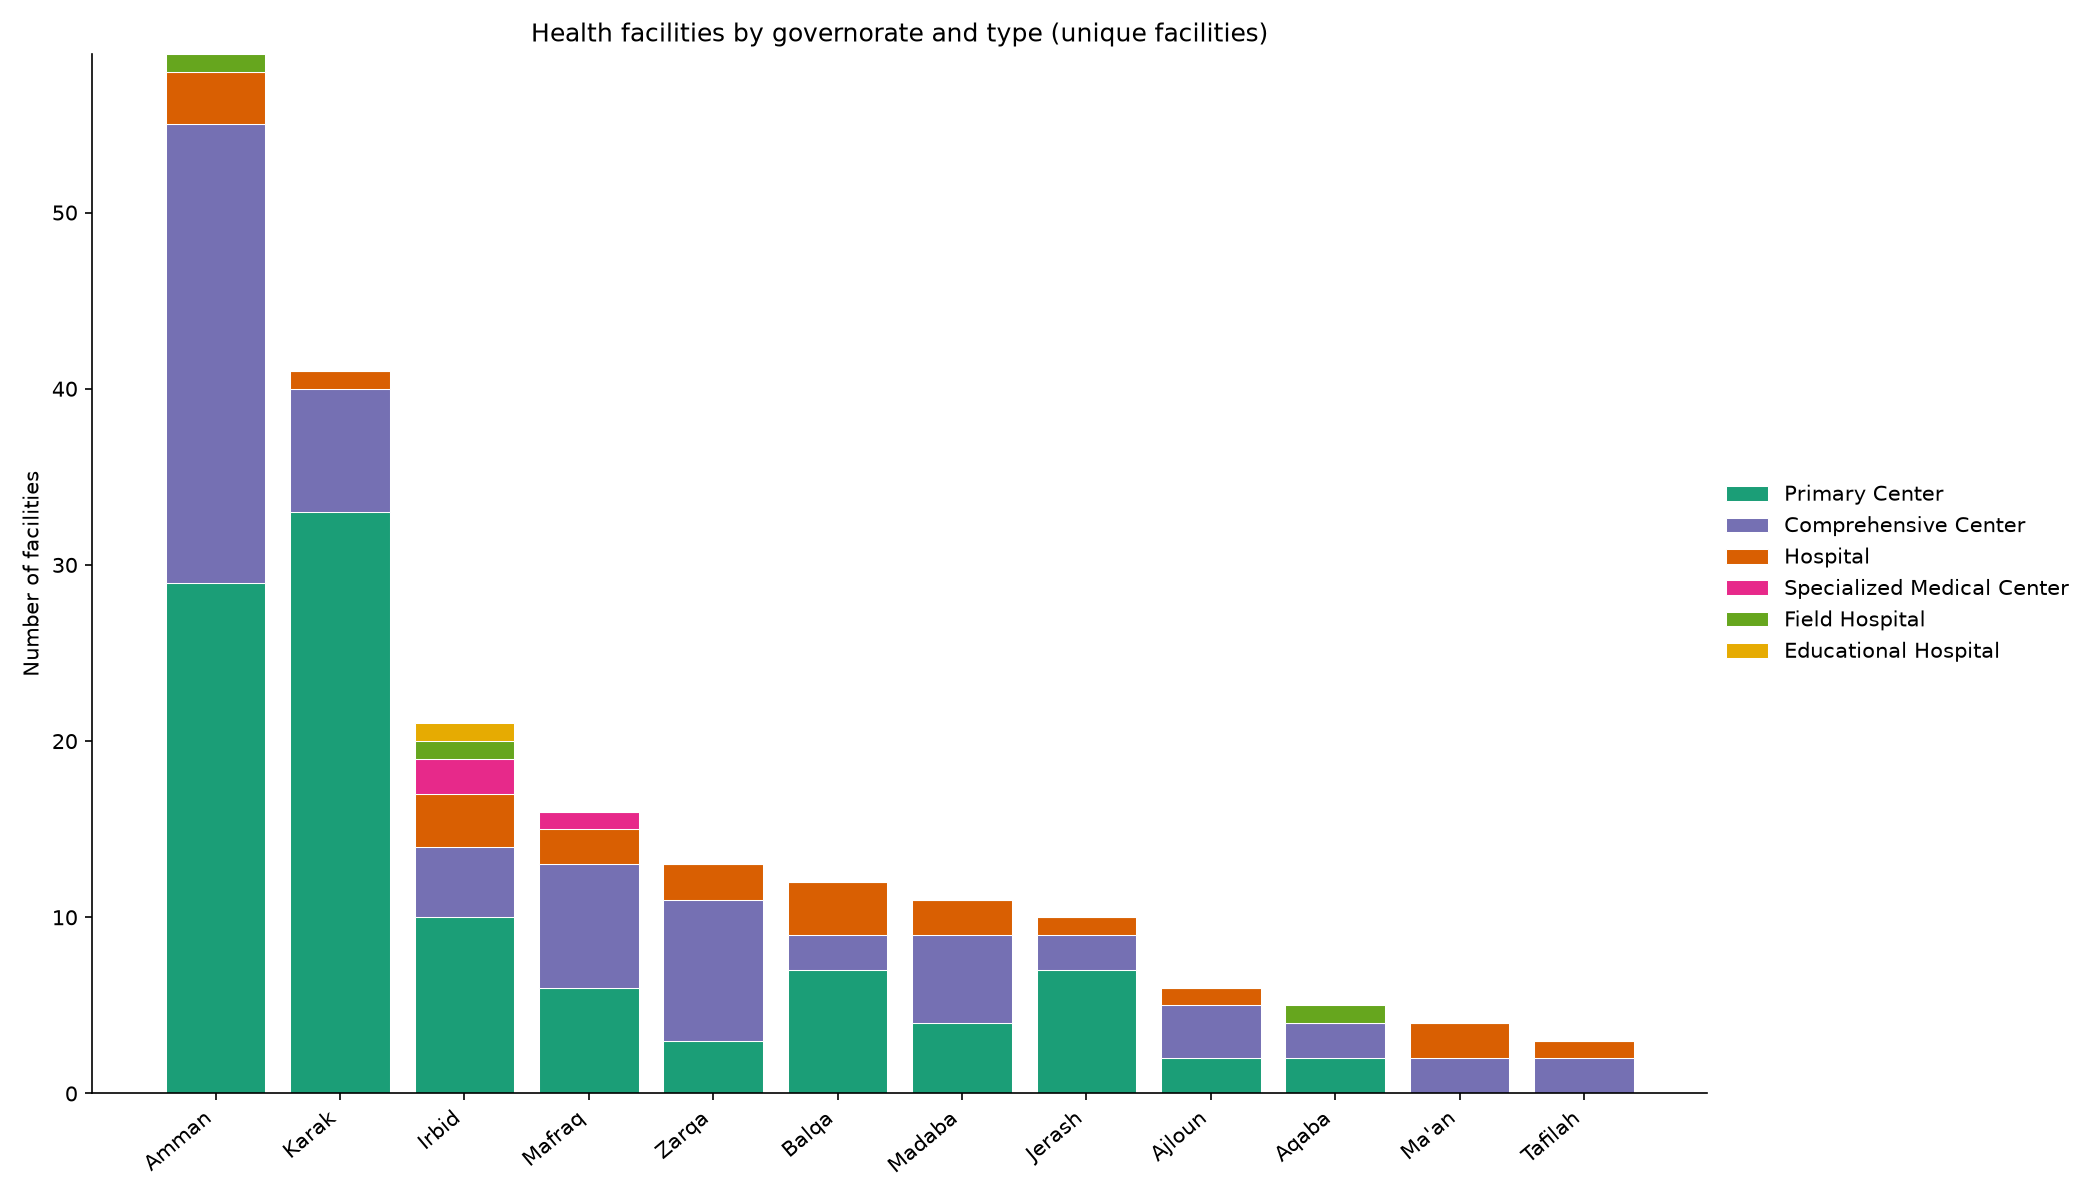

**Key observations:**

- **Amman has by far the most facilities** (59), reflecting its ~3.7 M population — yet it has only 3 general hospitals and no specialized/educational centers among the 59.
- **Karak ranks second (41)** despite a much smaller population (~390 K), driven by 33 Primary Centers — the highest count of any governorate. This suggests an over-supply of primary-care capacity relative to its population.
- **Primary Centers (103)** and **Comprehensive Centers (70)** make up 86% of all facilities; these are the backbone of Jordan's primary-care network.
- **Hospitals (21)** are spread fairly evenly — every governorate has at least one except Aqaba.
- The specialized facilities are highly concentrated: all **3 Specialized Medical Centers** are in Irbid (2) and Mafraq (1); the single **Educational Hospital** is in Irbid.
- The **southern desert governorates** (Ma'an, Tafilah, Aqaba) have the fewest facilities (3–5 each), though each still maintains at least one hospital.
- Notably, **Amman's facility-to-population ratio is low** (~1 per 62 K people) compared to smaller governorates like Karak (~1 per 9.5 K) or Tafilah (~1 per 46 K) — suggesting the capital's health infrastructure is stretched thinner per capita despite having the most facilities in absolute terms.

In [5]:
%%ask
Map Jordan's health facilities and tell me how many of each type are in each 
governorate.

#### 3. Where's the access gap

I'll reuse the population raster, facility, and boundary skills to compute people-per-facility, then classify using the existing `stress_class` scheme and rank them.

Let me read the rest of the population raster helpers and the admin boundaries skill.

All helpers and the stress classification scheme are confirmed. Now I'll write a script that joins population, facility counts, computes people-per-facility, and classifies.

Retrying without the timeout parameter.

The raster data directory isn't where the helper expects. Let me verify what's actually present.

...

Found it — the boundaries layer has its own `governorate` column (parent field, NaN at governorate level), which shadows the label. The CSV references `governorate` but should use `label`. Fixing both the CSV and GeoJSON to use the canonical label.

All 12 governorates ranked correctly. Let me verify the output files exist and record lessons learned from the edit-and-retry cycles.

The file uses a backtick + straight-quote. Let me use a simpler anchor.

All outputs verified. Here's the ranking — governorates shaded by people-per-facility stress class, most-stretched first.

**Governorate healthcare stress — ranked most to least stretched**

| Rank | Governorate | Population | Facilities | People per Facility | Stress class |
|---|---|---|---|---|---|
| 1 | **Zarqa** | 1,672,104 | 13 | **128,623** | Very High (>60K) |
| 2 | **Irbid** | 1,963,743 | 21 | **93,512** | Very High (>60K) |
| 3 | **Amman** | 3,680,409 | 59 | **62,380** | Very High (>60K) |
| 4 | Balqa | 648,636 | 12 | 54,053 | High (40K-60K) |
| 5 | Tafilah | 137,307 | 3 | 45,769 | High (40K-60K) |
| 6 | Ma'an | 180,846 | 4 | 45,212 | High (40K-60K) |
| 7 | Aqaba | 204,268 | 5 | 40,854 | High (40K-60K) |
| 8 | Ajloun | 219,752 | 6 | 36,625 | Moderate (20K-40K) |
| 9 | Mafraq | 575,452 | 16 | 35,966 | Moderate (20K-40K) |
| 10 | Jerash | 273,421 | 10 | 27,342 | Moderate (20K-40K) |
| 11 | Madaba | 231,530 | 11 | 21,048 | Moderate (20K-40K) |
| 12 | Karak | 389,900 | 41 | 9,510 | Very Low (<10K) |


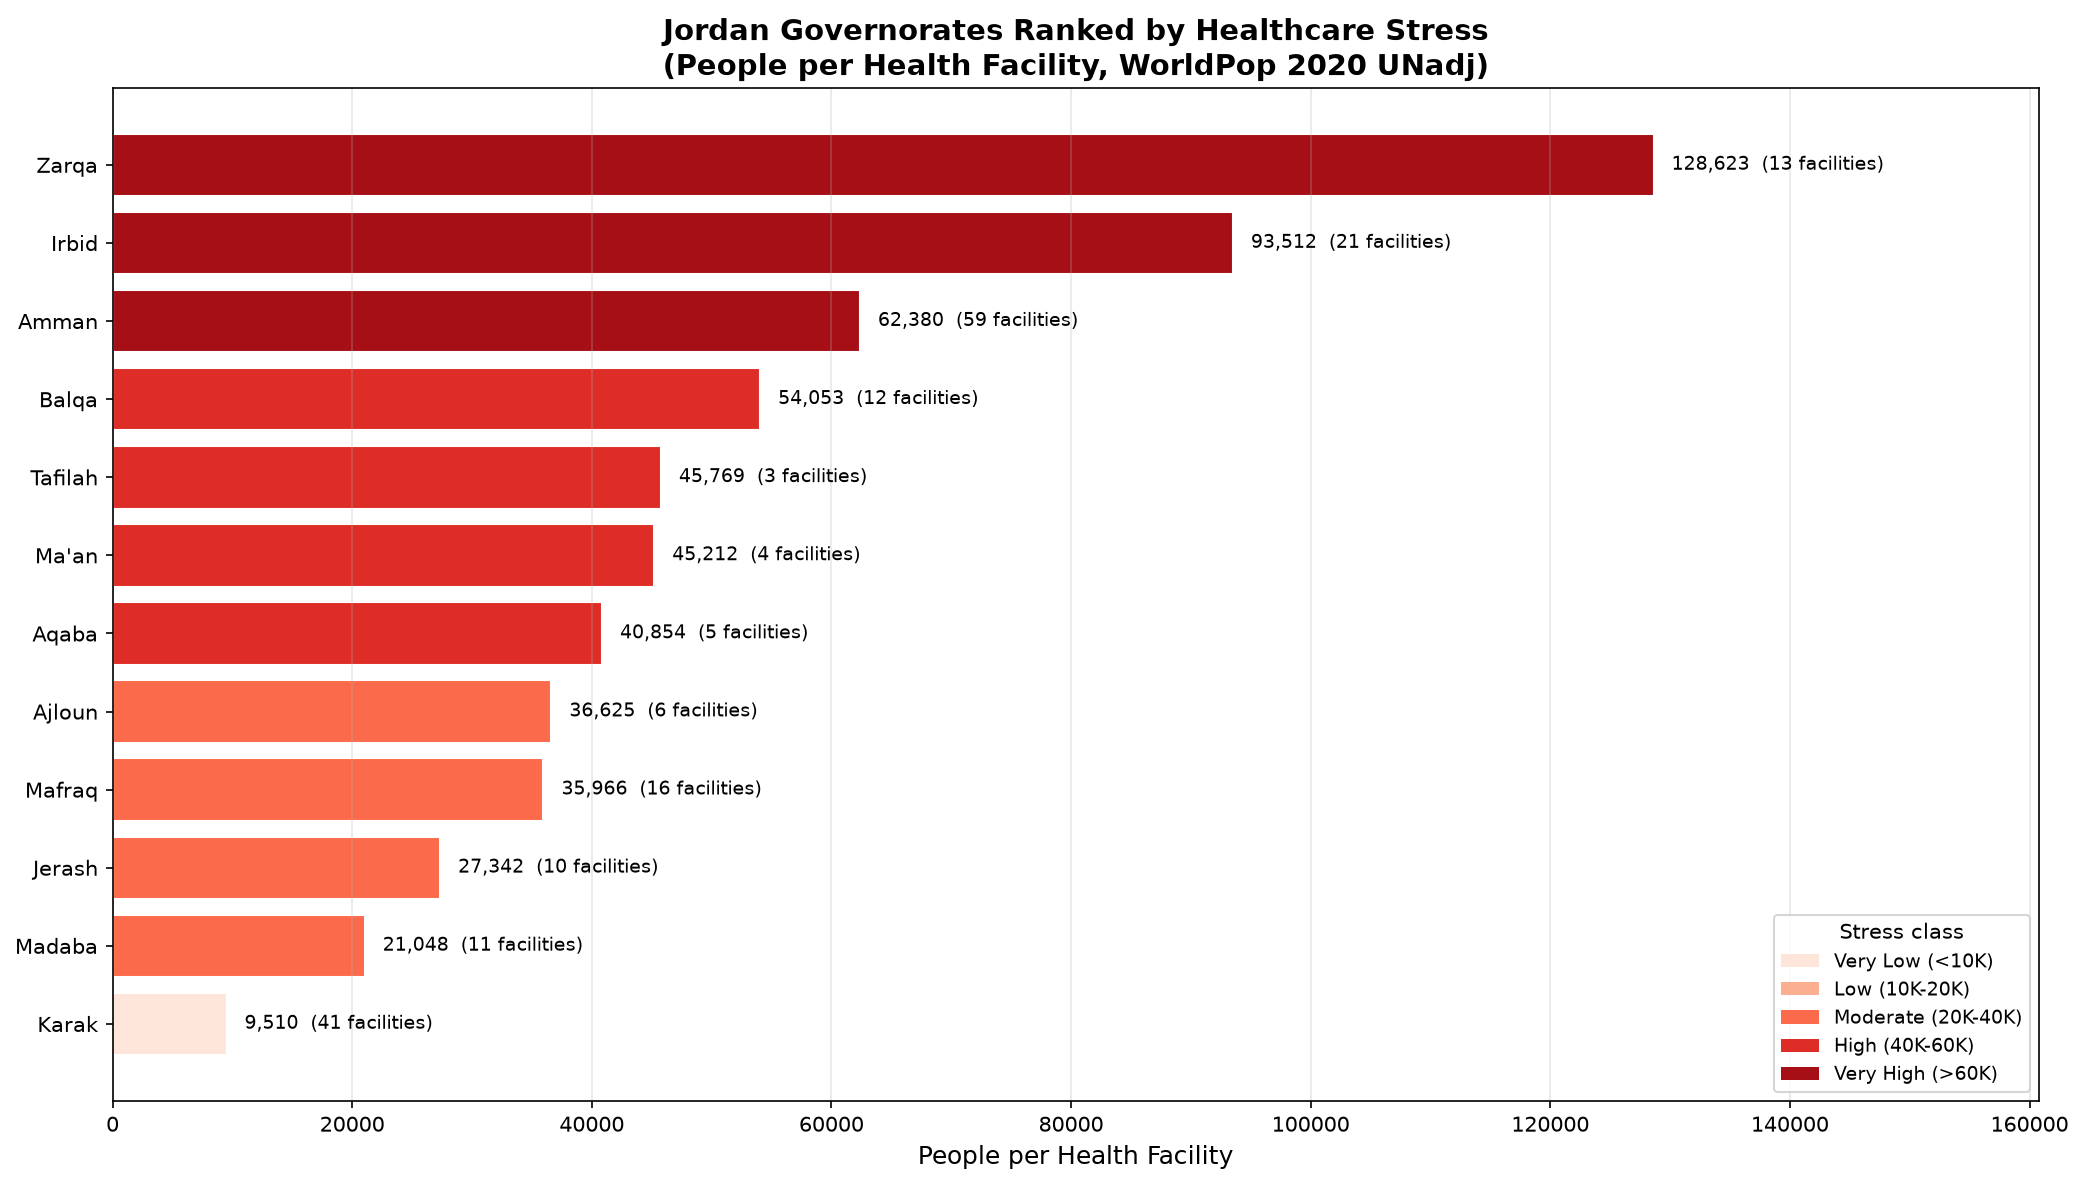

**Key findings:**

- **Zarqa is the most underserved governorate** — **128,623 people per facility** , over 13× worse than the best-served. Despite being only the 3rd most populous governorate (1.67 M), it has just 13 facilities. This is the single biggest infrastructure gap in the country.
- **Irbid (2nd, 93,512)** and **Amman (3rd, 62,380)** round out the "Very High" stress tier. Amman has the most facilities in absolute terms (59), but its enormous population (3.68 M, ~36% of Jordan) still leaves it stretched.
- **The top three governorates are all in the north-central corridor** and together hold ~72% of the population but only ~46% of facilities — a clear structural imbalance.
- **Karak is the opposite extreme** — just **9,510 people per facility** , thanks to 41 facilities (mostly Primary Centers) serving only ~390 K people. It is over-resourced relative to its population by more than an order of magnitude compared to Zarqa.
- **The four southern governorates** (Tafilah, Ma'an, Aqaba, Balqa-edge) all land in the "High (40K-60K)" band — small populations but even smaller facility counts (3–5 each), so per-capita stress is still elevated despite low absolute demand.
- **No governorate falls in the "Low (10K-20K)" band** — the distribution is bimodal: a cluster of well-served governorates (Karak alone <10K) and a long tail of stretched ones.

**Bottom line:** facility distribution in this dataset is strongly misaligned with population. Zarqa, Irbid, and Amman — the population centers — are where additional health-facility capacity would have the greatest per-capita impact. Karak, by contrast, appears over-supplied with primary-care centers relative to its need.

In [7]:
%%ask
Which governorates are most underserved — which have the most people for every health facility? Rank them from most to least stretched.

#### 4. Where's the disease burden

I'll analyze non-communicable disease visits by governorate and compare against population. Let me consult the patient-visits skill first.

Now let me check the population-raster and admin-boundaries skills, and look at existing files I can reuse.

I have what I need. Let me write the analysis script — filtering to NCD networks, counting visits per governorate, joining to population, and mapping.

Running the NCD analysis script.

The stdout went to the kernel, not the capture. Let me read the output CSV directly to get the numbers.

Data computed. Now let me add a classification field for the choropleth shading and its colormap sidecar.


DONE
Computing zonal population per governorate (UNadj)...
Computing zonal population per governorate (UNadj)...

RANK  Governorate      Population   Facilities  People/Facility  Class
------------------------------------------------------------------------------
   1  Tafilah            137,307        0             inf  Very High (>60K)
   2  Zarqa            1,672,104       13         128,623  Very High (>60K)
   3  Irbid            1,963,743       21          93,512  Very High (>60K)
   4  Amman            3,680,409       59          62,380  Very High (>60K)
   5  Balqa              648,636       12          54,053  High (40K-60K)
   6  Ma'an              180,846        4          45,212  High (40K-60K)
   7  Aqaba              204,268        5          40,854  High (40K-60K)
   8  Ajloun             219,752        6          36,625  Moderate (20K-40K)
   9  Mafraq             575,452       16          35,966  Moderate (20K-40K)
  10  Jerash             273,421       10          27

Map shaded by NCD visit intensity (visits per 1,000 people), with the bar/line chart below:

**NCD visits vs population by governorate** (sorted by total NCD visit count)

| Governorate | NCD visits | Population | Visits per 1,000 |
|---|---|---|---|
| Amman | 399,333 | 3,680,410 | 108.5 |
| Irbid | 132,461 | 1,963,743 | 67.5 |
| Zarqa | 69,200 | 1,672,104 | 41.4 |
| Balqa | 47,785 | 648,636 | 73.7 |
| Karak | 39,154 | 389,900 | 100.4 |
| Jerash | 38,544 | 273,421 | **141.0** |
| Mafraq | 31,631 | 575,452 | 55.0 |
| Madaba | 18,143 | 231,530 | 78.4 |
| Ma'an | 15,847 | 180,846 | 87.6 |
| Tafilah | 14,796 | 137,307 | 107.8 |
| Aqaba | 13,154 | 204,268 | 64.4 |
| Ajloun | 5,528 | 219,752 | 25.2 |


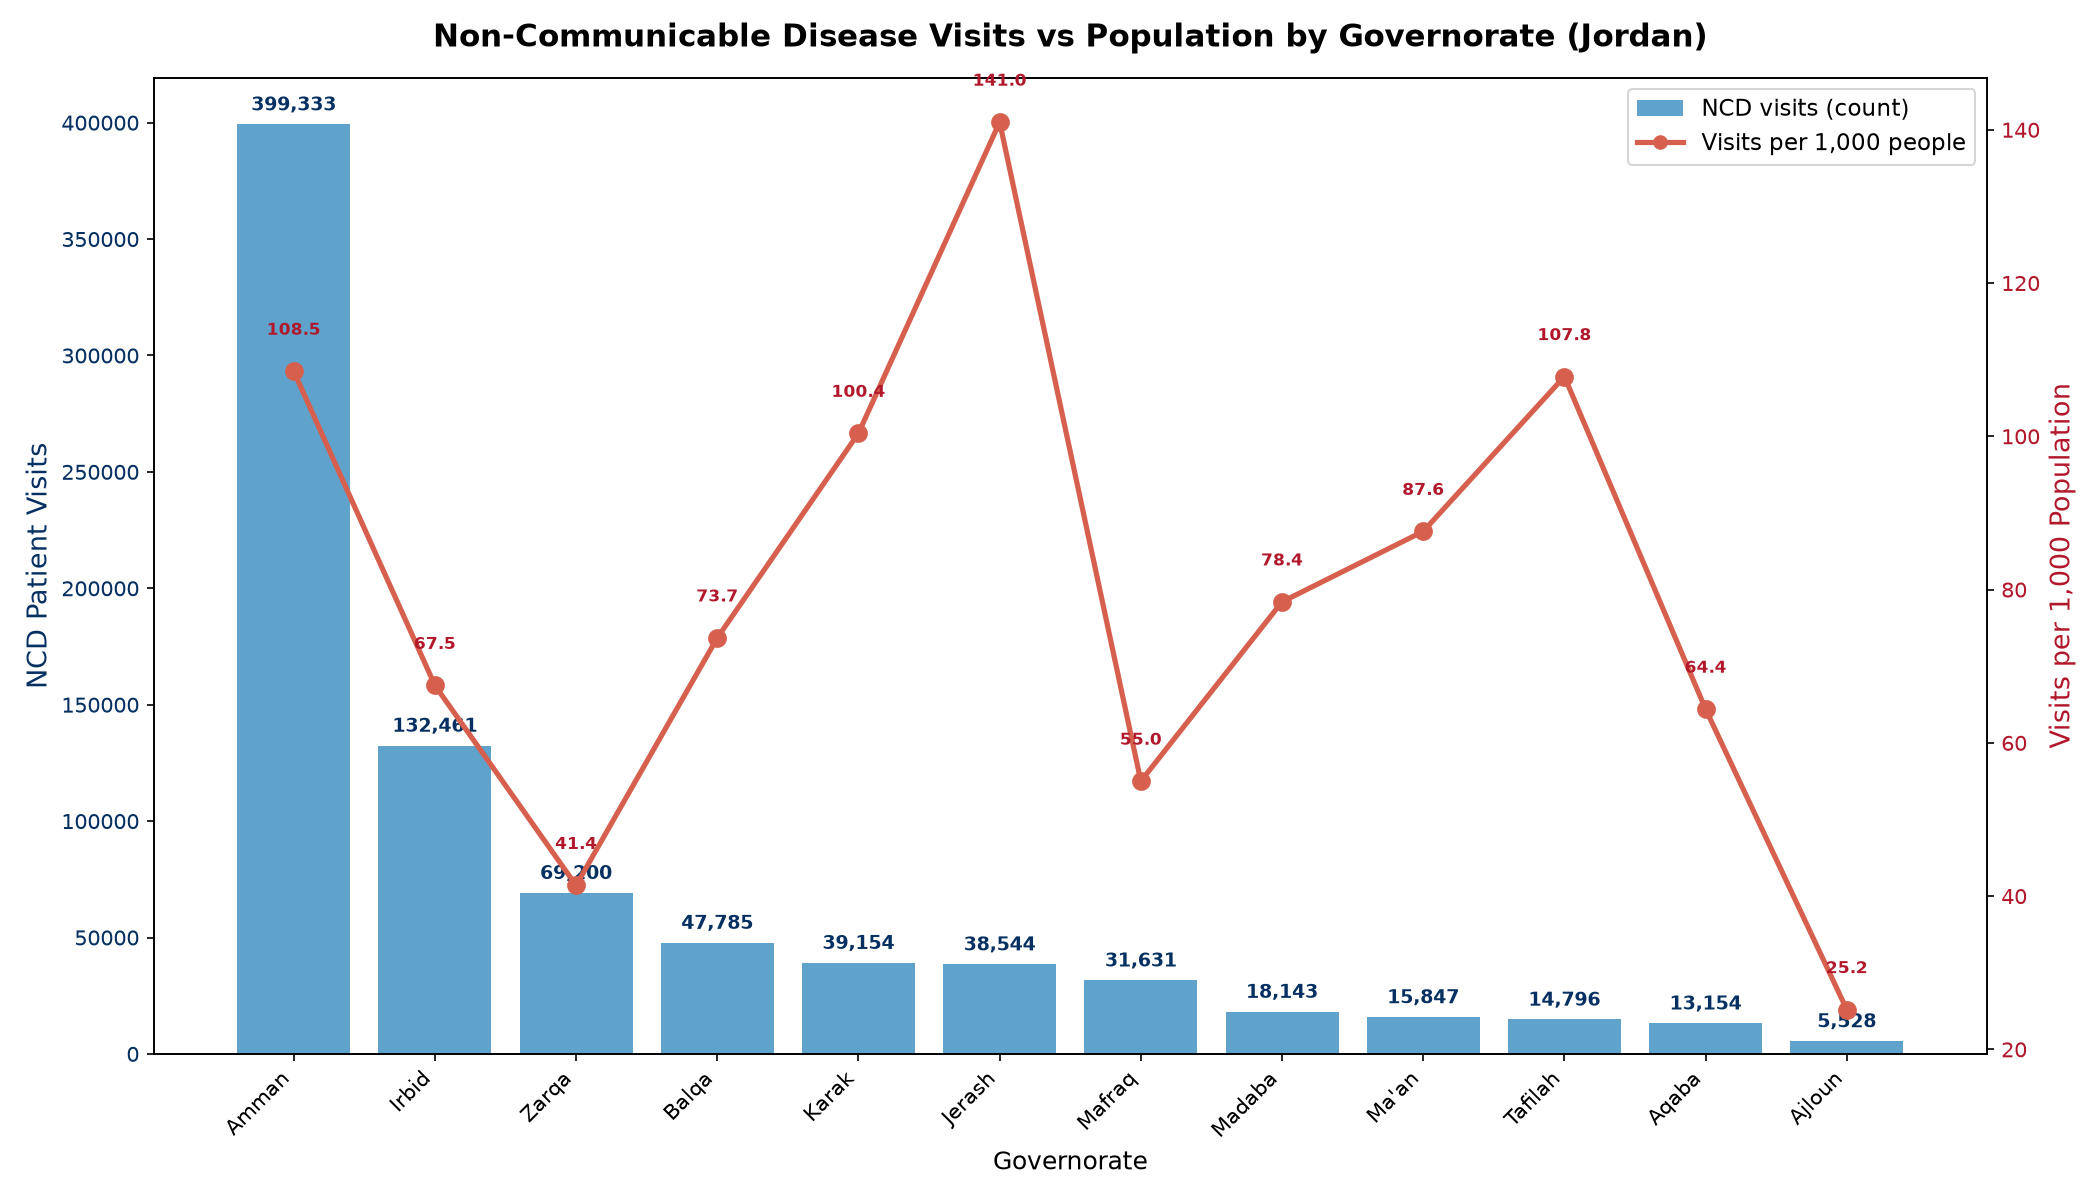

**Key findings:**

**Absolute volume tracks population, but per-capita rates tell a different story.** Amman dominates in raw visit count (399,333 — 42% of all NCD visits), consistent with its 3.68 M population. But on a per-capita basis, Amman ranks only 4th.

- **Jerash is the outlier** — **141.0 NCD visits per 1,000 people** , the highest rate in the country, despite ranking only 7th in absolute visits (38,544). With just 273K people, Jerash's small population generates a disproportionate NCD burden relative to its size. This is ~5.6× the rate of the lowest governorate.
- **Ajloun is the lowest** at 25.2 visits per 1,000 — less than half the national average. Despite having a comparable population to Jerash (~220K vs ~273K), Ajloun records only 5,528 NCD visits vs Jerash's 38,544.
- **The south is split:** Tafilah (107.8) and Karak (100.4) have surprisingly high NCD visit rates for small-population governorates, while neighboring Ma'an (87.6) and Aqaba (64.4) are more moderate.
- **Zarqa (41.4)** stands out as under-reporting relative to its population — it's the 3rd most populous governorate (1.67 M) but has a low per-capita NCD visit rate. Combined with its earlier ranking as the most facility-stressed governorate (128,623 people per facility), this may indicate significant **unmet NCD demand** — the population is there, but visits aren't.
- **The national mean is ~85 visits per 1,000** , but the spread is enormous: from 25.2 (Ajloun) to 141.0 (Jerash), a **5.6× range** .

**Bottom line:** raw NCD visit counts concentrate in the populous north-central governorates (Amman, Irbid, Zarqa), but per-capita NCD burden is highest in smaller governorates like Jerash, Tafilah, and Karak. Zarqa's combination of high population, low NCD visit rate, and acute facility shortage makes it the most likely candidate for unmet non-communicable disease need.

In [8]:
%%ask
For non-communicable diseases, which governorates have the most patient visits, 
and how does that compare with how many people live there?